In [38]:
import yfinance as yf
import random 
import pandas as pd
import numpy as np

random.seed(6666)

In [39]:
goog_data = yf.download('GOOG','2001-01-01', '2018-01-01')


[*********************100%***********************]  1 of 1 completed


In [40]:
signals = pd.DataFrame(index = goog_data.index)
portfolio = pd.DataFrame(index = goog_data.index)
signals.shape

(3366, 0)

In [49]:
signals['signal'] = np.random.randint(-1,2, size = len(signals))
portfolio['orders'] = signals['signal'].diff()

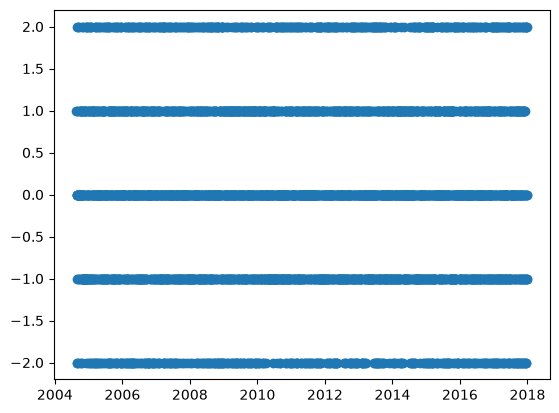

In [64]:
import matplotlib.pyplot as plt

plt.scatter(portfolio.index, portfolio)

In [63]:
goog_data.loc['2004-08-19']

Price   Ticker
Close   GOOG      2.477292e+00
High    GOOG      2.569134e+00
Low     GOOG      2.369154e+00
Open    GOOG      2.468896e+00
Volume  GOOG      8.974272e+08
Name: 2004-08-19 00:00:00, dtype: float64

In [ ]:
# start with initial capital of $10,000
# display holding value, total value, cash value. 
# these functions calculate change in each value. The main function should calculate change in shares
# first. 

def typ_price(close, low, high) -> int:
    return (close + low + high) / 3

def cash_value(initial: int, order: int, date: pd.Timestamp, ticker_price: pd.DataFrame) -> int:
    '''
    Calculates the cash value of the portfolio for the day.
    '''

    dayta = ticker_price.loc[date]
    day_price = typ_price(dayta['Close'], dayta['Low'], dayta['High'])

    return initial - day_price * order

def holding_value(shares: int, order: int, date: Date, ticker_price: pd.DataFrame) -> int:
    '''
    Calculates holding value of the portfolio
    '''

    dayta = ticker_price.loc[date]
    day_price = typ_price(dayta['Close'], dayta['Low'], dayta['High'])

    return shares * day_price

def total_value(cash_value: int, holding_value: int) -> int:
    '''
    Calculates total value of the portfolio
    '''
    
    return cash_value + holding_value

In [95]:
# main function: creates 3 lists, which will then be appended to the portfolio dataframe. 
# FIRST: find change in shares owned, then calculate cash val, holding val, and total val. 

shares_owned = [0]
cash_val = [10000]
holding_v = [0]
total_val = [10000]

for i, orders in portfolio.iterrows(): # currently, portfolio just has orders.
    shares_owned.append(shares_owned[len(shares_owned) - 1] + orders)
    new_cash = cash_value(cash_val[len(cash_val) - 1], orders, i, goog_data)
    cash_val.append(new_cash)
    new_hold = holding_value(shares_owned[len(shares_owned) - 1], orders, i, goog_data)
    holding_v.append(new_hold)
    total_val.append(total_value(new_cash, new_hold))

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Series'

In [91]:
portfolio['cash value'] = cash_val[1:]
portfolio['holding value'] = holding_v[1:]
portfolio['total value'] = total_val[1:]